In [1]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv("advanced_student_performance (1).csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   course_name      520 non-null    str    
 1   class_number     520 non-null    int64  
 2   study_hours      520 non-null    float64
 3   last_exam_score  520 non-null    int64  
 4   exam_score       520 non-null    int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 20.4 KB


In [6]:
df = df.drop("course_name",axis=1)

In [7]:
df.corr()

,class_number,study_hours,last_exam_score,exam_score
class_number,1.000000,0.084937,-0.004604,0.049488
study_hours,0.084937,1.000000,0.083547,0.814083
last_exam_score,-0.004604,0.083547,1.000000,0.426481
exam_score,0.049488,0.814083,0.426481,1.000000


<Axes: xlabel='study_hours', ylabel='exam_score'>

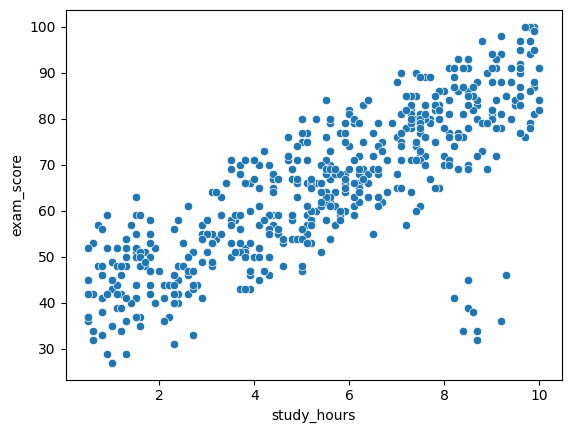

In [10]:
sns.scatterplot(x=df["study_hours"],y=df["exam_score"])

* The relation between the target column and feature column is strong so, the data is linear.
* The target column is dependent on study hours 

In [11]:
X = df[["class_number","study_hours","last_exam_score"]]
y = df["exam_score"]

In [12]:
model = LinearRegression()

In [15]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=42)

In [23]:
xtrain

,class_number,study_hours,last_exam_score
434,2,6.0,78
436,2,4.3,36
208,2,6.0,99
332,1,3.9,30
220,4,8.7,36
...,...,...,...
71,1,1.3,87
106,1,2.7,41
270,3,4.4,69
435,1,3.1,33


In [16]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_train_pred = model.predict(xtrain)

In [18]:
y_test_pred = model.predict(xtest)

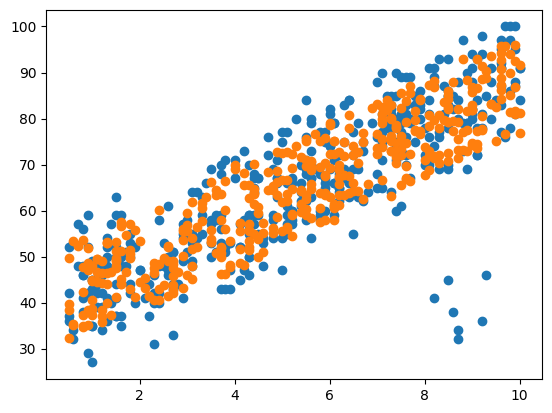

In [25]:
plt.scatter(xtrain.iloc[:,1],ytrain)
plt.scatter(xtrain.iloc[:,1],y_train_pred)

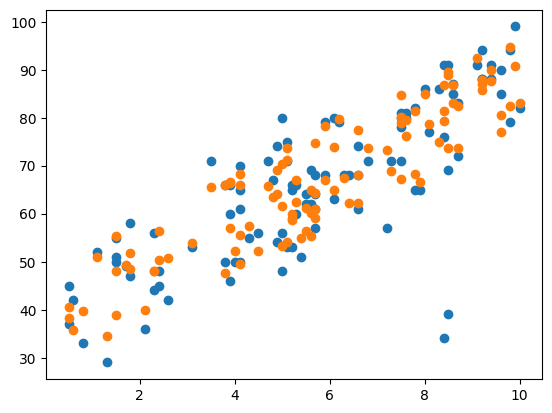

In [26]:
plt.scatter(xtest.iloc[:,1],ytest)
plt.scatter(xtest.iloc[:,1],y_test_pred)

In [30]:
r2_train = r2_score(ytrain,y_train_pred)
r2_train

0.8098683440619251

In [32]:
r2_test = r2_score(ytest, y_test_pred)
r2_test

0.7122420965788003

* Both Train Score is good so the model is good fit